##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Models
from sklearn.tree import DecisionTreeClassifier

##Load Dataset

In [ ]:
df = pd.read_csv("/content/cleaned_preprocessed_disaster_data.csv")

df.head()

,iso3,country,disaster_type,year,deaths,affected,mng_cap,inventory,distance,priority_tier
0,BRA,Brazil,Flood,2018,4.0,250.0,4.247241,1664,120,Moderate
1,USA,United States of America,Wildfire,2002,0.0,1572.0,7.704286,1817,218,Low
2,RWA,Rwanda,Flood,2022,3.0,0.0,6.391964,662,448,Moderate
3,USA,United States of America,Drought,2024,0.0,0.0,5.591951,211,187,Critical
4,IDN,Indonesia,Road,2022,10.0,20.0,2.936112,705,434,Critical


##Encode Categorical Columns

In [ ]:
le = LabelEncoder()

df['iso3'] = le.fit_transform(df['iso3'])
df['country'] = le.fit_transform(df['country'])
df['disaster_type'] = le.fit_transform(df['disaster_type'])
df['priority_tier'] = le.fit_transform(df['priority_tier'])

##Define Features and Target

In [ ]:
X = df.drop("priority_tier", axis=1)
y = df["priority_tier"]

##Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Define Model

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

##Predictions

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

##Accuracy

In [ ]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


##Model Classes

In [ ]:
print(model.classes_)
print(le.classes_)

[0 1 2]
['Critical' 'Low' 'Moderate']


##Adjust_priority

In [ ]:
def adjust_priority(prob):

    critical_prob = prob[0]
    low_prob = prob[1]
    moderate_prob = prob[2]

    if critical_prob > 0.85:
        return 0
    elif moderate_prob > 0.50:
        return 2
    else:
        return 1

##adjust_prediction

In [ ]:
adjusted_pred = [adjust_priority(p) for p in probabilities]

In [ ]:

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 1.0
Test Accuracy: 0.9814980602805132


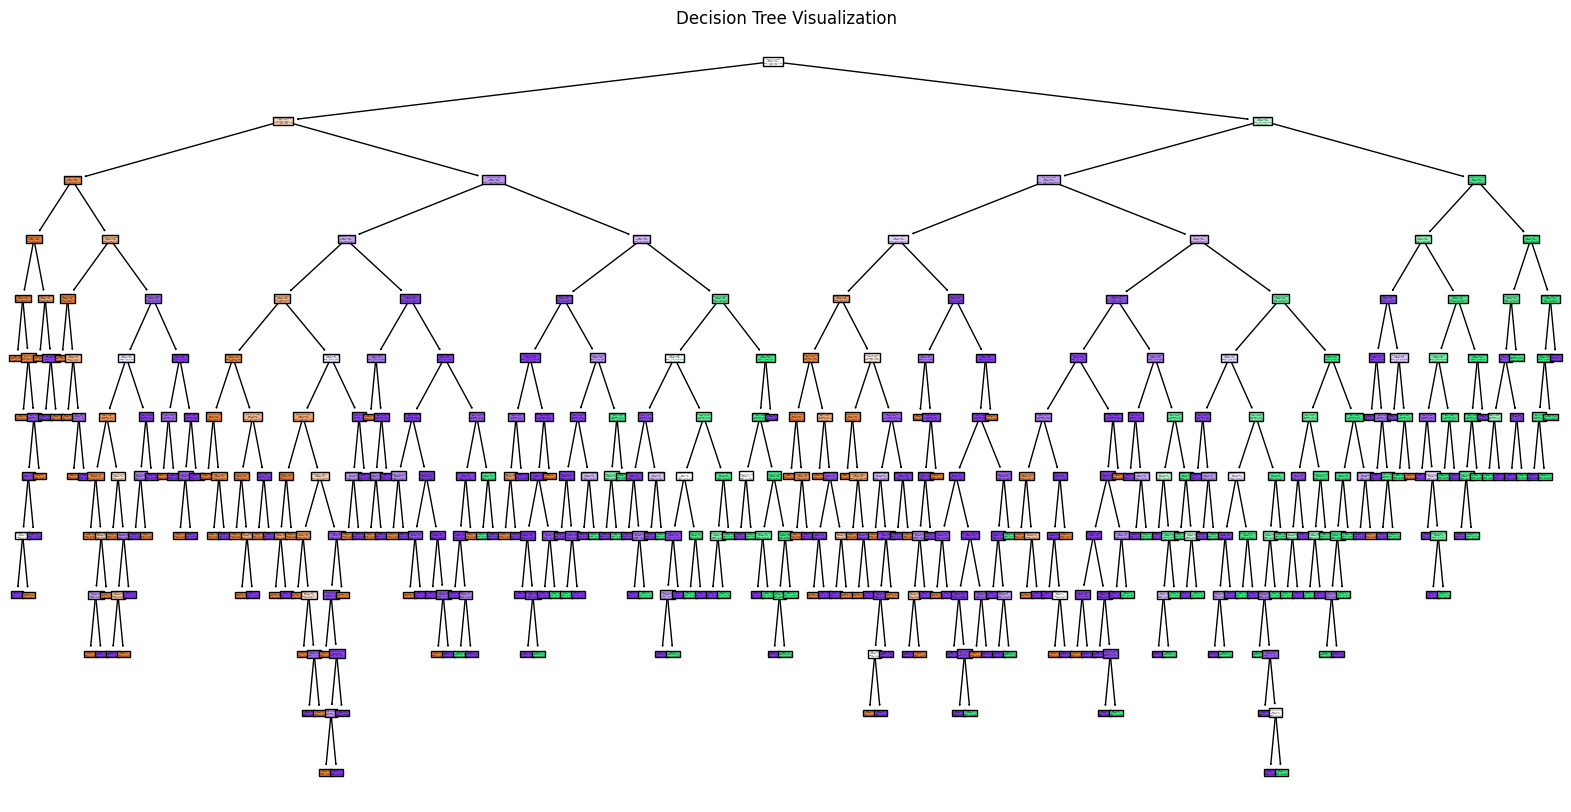

In [ ]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low", "Moderate", "Critical"],
    filled=True
)

plt.title("Decision Tree Visualization")

plt.show()

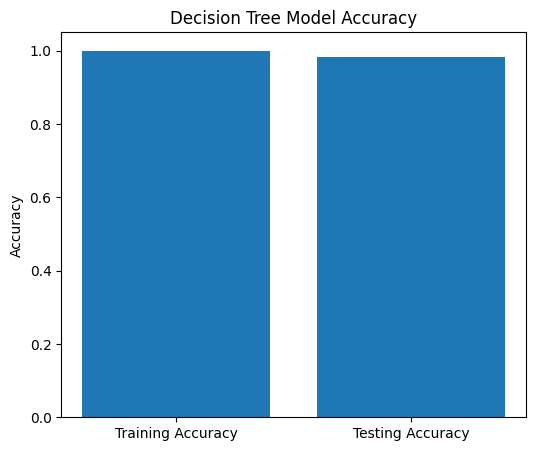

In [ ]:
import matplotlib.pyplot as plt

accuracies = [train_accuracy, test_accuracy]
labels = ["Training Accuracy", "Testing Accuracy"]

plt.figure(figsize=(6,5))
plt.bar(labels, accuracies)

plt.ylabel("Accuracy")
plt.title("Decision Tree Model Accuracy")

plt.show()